Step 1: Loading data...
Step 2: Generating Visualizations...


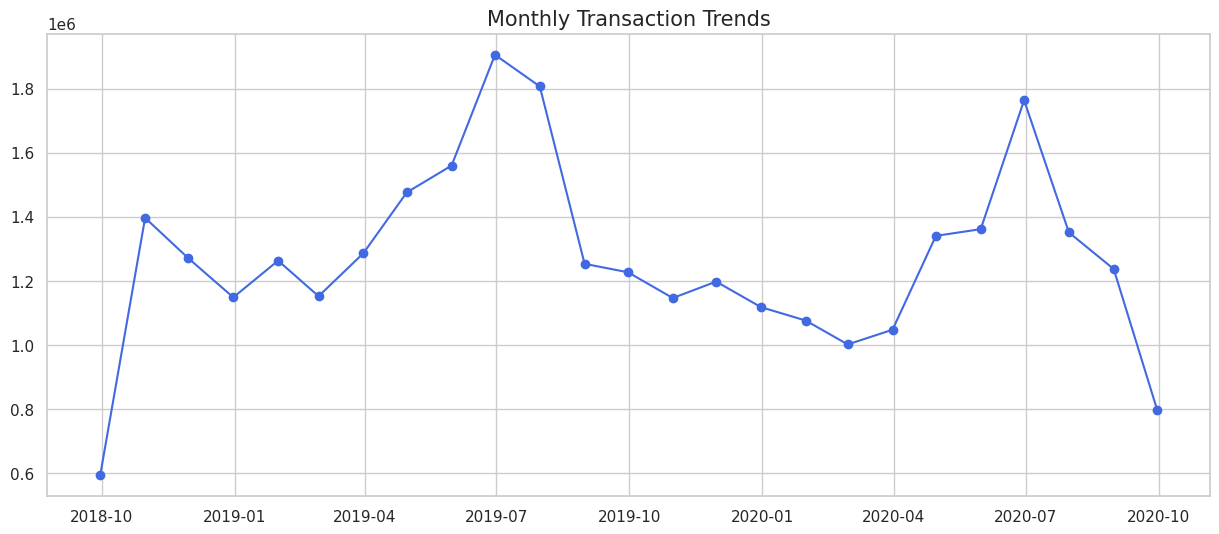

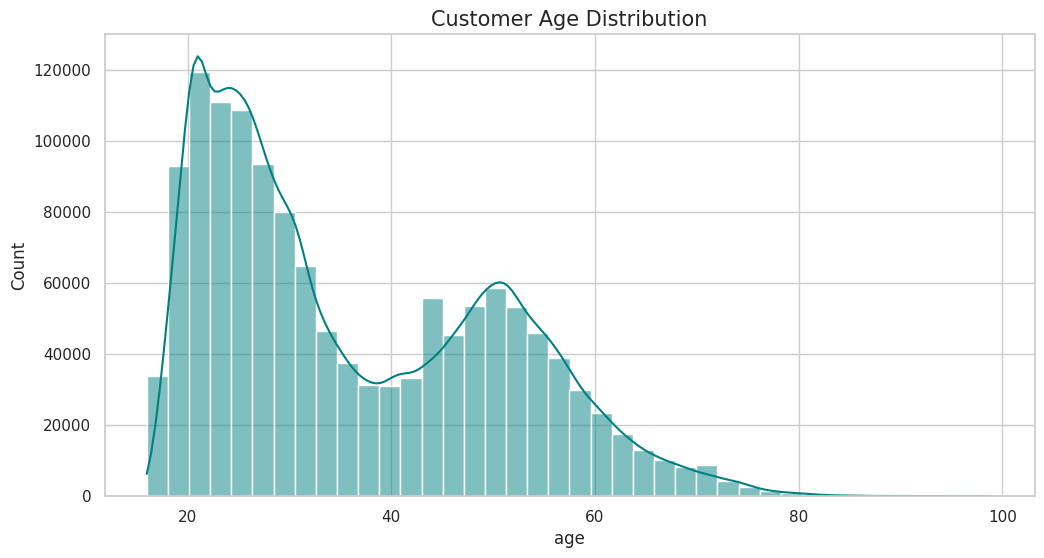

Plotting Category Heatmap...


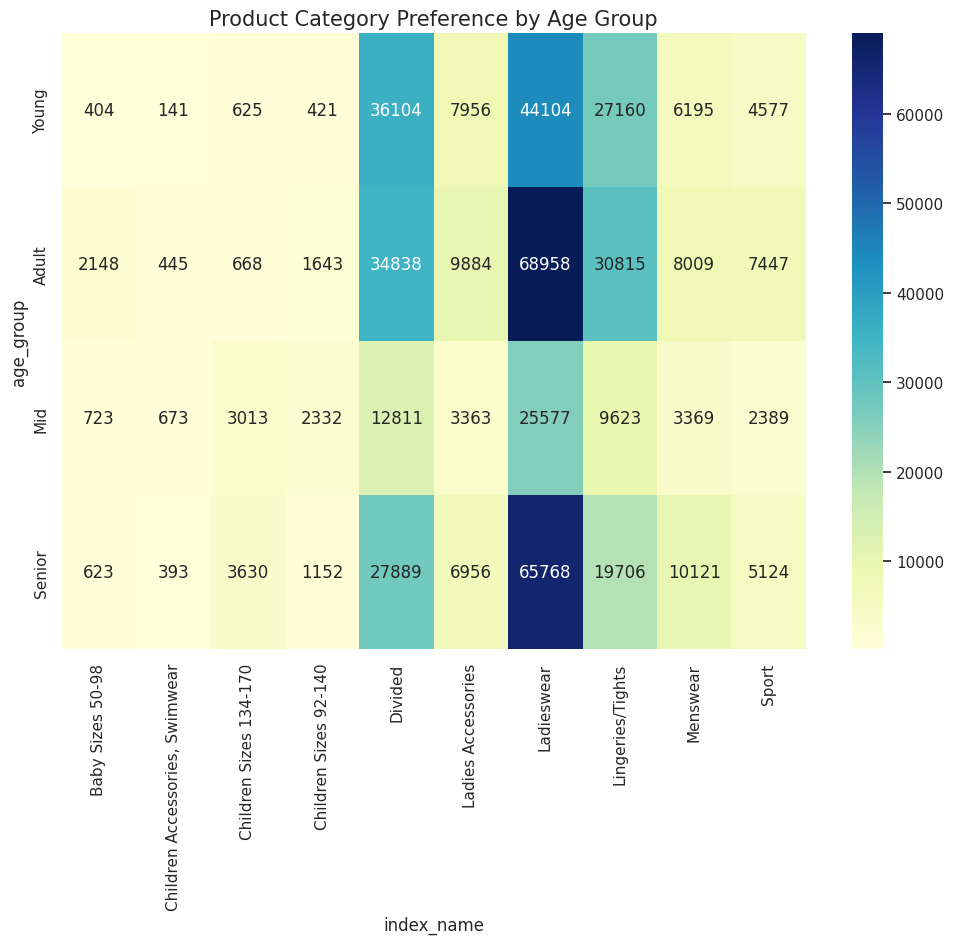

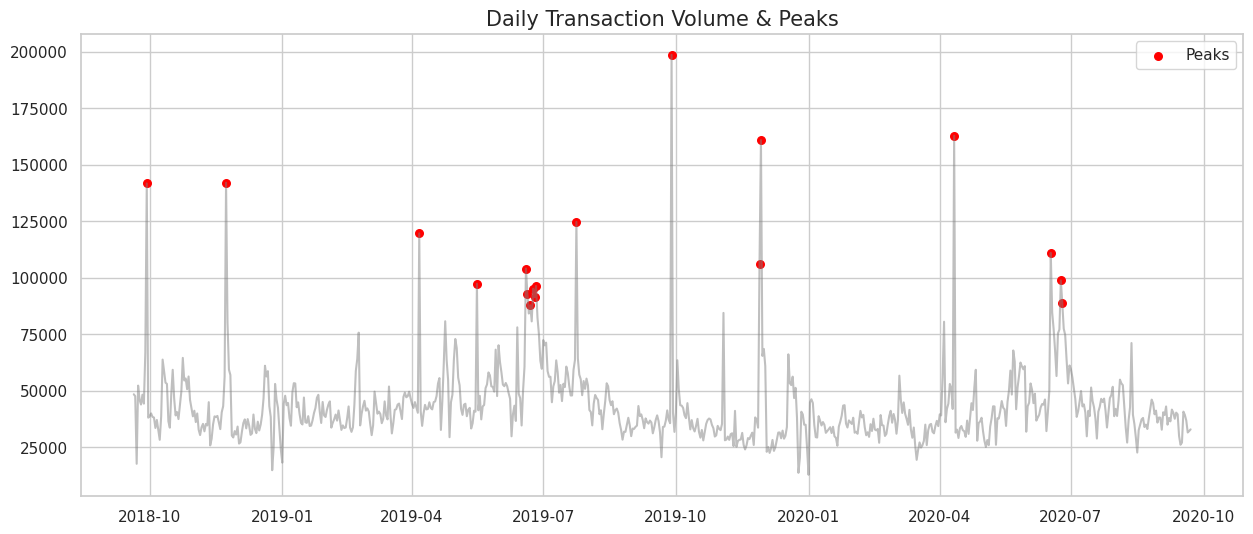

Step 3: Building Recommendation Model...


Processing Pairs: 100%|██████████| 243578/243578 [00:02<00:00, 87551.14it/s]


Step 4: Final Inference...


100%|██████████| 1371980/1371980 [00:08<00:00, 157309.42it/s]


Finished! No more warnings.


In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
from collections import defaultdict
import gc

# ====================================================
# 1. 环境与数据加载
# ====================================================
DATA_PATH = Path('/kaggle/input/competitions/h-and-m-personalized-fashion-recommendations')

def hex_to_int(s):
    return int(s[-16:], 16)

print("Step 1: Loading data...")
articles = pd.read_csv(DATA_PATH / 'articles.csv')
customers = pd.read_csv(DATA_PATH / 'customers.csv')
trans_all = pd.read_csv(DATA_PATH / 'transactions_train.csv', usecols=['t_dat', 'customer_id', 'article_id'])
trans_all['t_dat'] = pd.to_datetime(trans_all['t_dat'])

# ====================================================
# 2. 可视化图表集 (EDA Section)
# ====================================================
print("Step 2: Generating Visualizations...")
sns.set_theme(style="whitegrid")

# 图 1：月度交易趋势图 (使用 ME 避免警告)
plt.figure(figsize=(15, 6))
monthly_trans = trans_all.set_index('t_dat').resample('ME').size()
plt.plot(monthly_trans.index, monthly_trans.values, marker='o', color='royalblue')
plt.title('Monthly Transaction Trends', fontsize=15)
plt.show()

# 图 2：用户年龄分布图
plt.figure(figsize=(12, 6))
sns.histplot(customers['age'].dropna(), bins=40, kde=True, color='teal')
plt.title('Customer Age Distribution', fontsize=15)
plt.show()

# 图 3：商品品类热力图 (修复 observed=True 警告)
print("Plotting Category Heatmap...")
temp_customers = customers[['customer_id', 'age']].copy()
temp_customers['customer_id'] = temp_customers['customer_id'].apply(hex_to_int).astype('int64')
# 生成分类数据 age_group
temp_customers['age_group'] = pd.cut(temp_customers['age'], bins=[0, 25, 35, 45, 100], labels=['Young', 'Adult', 'Mid', 'Senior'])

temp_trans = trans_all.sample(500000).copy()
temp_trans['customer_id'] = temp_trans['customer_id'].apply(hex_to_int).astype('int64')
temp_trans = temp_trans.merge(temp_customers[['customer_id', 'age_group']], on='customer_id')
temp_trans = temp_trans.merge(articles[['article_id', 'index_name']], on='article_id')

plt.figure(figsize=(12, 8))
# 【修复点】：显式设置 observed=True
pivot_table = temp_trans.groupby(['age_group', 'index_name'], observed=True).size().unstack()
sns.heatmap(pivot_table, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Product Category Preference by Age Group', fontsize=15)
plt.show()

# 图 4：异常峰值检测图
plt.figure(figsize=(15, 6))
daily_trans = trans_all.groupby('t_dat').size()
plt.plot(daily_trans.index, daily_trans.values, color='gray', alpha=0.5)
outliers = daily_trans[daily_trans > daily_trans.mean() + 2.5 * daily_trans.std()]
plt.scatter(outliers.index, outliers.values, color='red', s=30, label='Peaks')
plt.title('Daily Transaction Volume & Peaks', fontsize=15)
plt.legend()
plt.show()

# 清理绘图产生的临时变量
del temp_trans, temp_customers, pivot_table, monthly_trans, daily_trans
gc.collect()

# ====================================================
# 3. 核心推荐模型逻辑
# ====================================================
print("Step 3: Building Recommendation Model...")

# ID 转换与时间范围锁定
trans_all['customer_id'] = trans_all['customer_id'].apply(hex_to_int).astype('int64')
last_date = trans_all['t_dat'].max()

# 热门商品 (最后一周)
last_week_pop = trans_all[trans_all['t_dat'] > last_date - pd.Timedelta(days=7)]
top12_strs = ['0' + str(x) for x in last_week_pop['article_id'].value_counts().index[:12]]

# 复购与关联 (最后三周)
train_recent = trans_all[trans_all['t_dat'] > last_date - pd.Timedelta(days=21)].copy()

# 关联规则 (Association Rules)
vc = train_recent.groupby(['customer_id', 't_dat'])['article_id'].apply(list)
pairs = defaultdict(lambda: defaultdict(int))
for items in tqdm(vc, desc="Processing Pairs"):
    if len(items) > 1:
        for i in range(len(items)):
            for j in range(i + 1, len(items)):
                pairs[items[i]][items[j]] += 1
                pairs[items[j]][items[i]] += 1
top_pairs = {item: sorted(related.items(), key=lambda x: x[1], reverse=True)[0][0] 
             for item, related in pairs.items()}

# 复购缓存
user_recent_buys = train_recent.sort_values(['customer_id', 't_dat'], ascending=[True, False]).groupby('customer_id')['article_id'].unique().to_dict()

# ====================================================
# 4. 生成提交
# ====================================================
print("Step 4: Final Inference...")
sub = pd.read_csv(DATA_PATH / 'sample_submission.csv', usecols=['customer_id'])
sub['customer_id_int'] = sub['customer_id'].apply(hex_to_int).astype('int64')

final_preds = []
for c_id in tqdm(sub['customer_id_int'].values):
    res = []
    history = user_recent_buys.get(c_id, [])
    
    # 1. 复购
    for item in history:
        res.append('0' + str(item))
        if len(res) >= 12: break
    # 2. 关联
    if len(res) < 12:
        for item in history:
            if item in top_pairs:
                p_str = '0' + str(top_pairs[item])
                if p_str not in res: res.append(p_str)
            if len(res) >= 12: break
    # 3. 热门补位
    if len(res) < 12:
        for item_str in top12_strs:
            if item_str not in res: res.append(item_str)
            if len(res) >= 12: break
    final_preds.append(' '.join(res))

sub['prediction'] = final_preds
sub[['customer_id', 'prediction']].to_csv('submission.csv', index=False)
print("Finished! No more warnings.")